In [1]:
import argparse
import os
import glob
import pickle
import pandas as pd
import numpy as np
import pprint
from datetime import datetime
from sklearn.metrics import roc_auc_score

In [2]:
# Build a .py script that takes a snapshot date, loads a model artefact and make an inference and save to datamart

## Configuration

In [3]:
snapshot_date_str = "2024-09-01"
modelname = "credit_model_2024_09_01.pkl"

In [4]:
# --- Configuration ---
config = {}
config["snapshot_date_str"] = snapshot_date_str
config["snapshot_date"] = datetime.strptime(config["snapshot_date_str"], "%Y-%m-%d")
config["model_bank_directory"] = "model_bank/"
config["predictions_directory"] = "datamart/gold/model_predictions/"
config["label_store_directory"] = "datamart/gold/label_store/"
config["drift_flag_path"] = "datamart/gold/model_drift_detected.flag"
config["drift_threshold"] = -0.05  # Drop in AUC beyond 5% → drift
config["model_name"] = modelname
config["model_bank_directory"] = "model_bank/"
config["model_artefact_filepath"] = config["model_bank_directory"] + config["model_name"]

pprint.pprint(config)

{'drift_flag_path': 'datamart/gold/model_drift_detected.flag',
 'drift_threshold': -0.05,
 'label_store_directory': 'datamart/gold/label_store/',
 'model_artefact_filepath': 'model_bank/credit_model_2024_09_01.pkl',
 'model_bank_directory': 'model_bank/',
 'model_name': 'credit_model_2024_09_01.pkl',
 'predictions_directory': 'datamart/gold/model_predictions/',
 'snapshot_date': datetime.datetime(2024, 9, 1, 0, 0),
 'snapshot_date_str': '2024-09-01'}


## Load latest model artefact

In [5]:
model_files = glob.glob(os.path.join(config["model_bank_directory"], "*.pkl"))
if not model_files:
    print("No model found in model_bank — skipping monitoring.")
    
else: 
    latest_model_file = max(model_files, key=os.path.getctime)
    print(f"Found latest model: {latest_model_file}")
    
    with open(latest_model_file, "rb") as f:
        lastest_model_artefact = pickle.load(f)
    
    lastest_model_version = lastest_model_artefact["model_version"]
    lastest_training_auc = lastest_model_artefact["results"]["auc_oot"]
    print(f"Lastest Model version: {lastest_model_version}, training OOT AUC: {lastest_training_auc:.4f}")

with open(config['model_artefact_filepath'], "rb") as f:
    prd_model_artefact = pickle.load(f)

prd_model_version = prd_model_artefact["model_version"]
prd_training_auc = prd_model_artefact["results"]["auc_oot"]
print(f"Production Model version: {prd_model_version}, training OOT AUC: {prd_training_auc:.4f}\n")

Found latest model: model_bank/credit_model_2024_12_01.pkl
Lastest Model version: credit_model_2024_12_01, training OOT AUC: 0.7688
Production Model version: credit_model_2024_09_01, training OOT AUC: 0.8026



## Load latest predictions

In [6]:
pred_folder = os.path.join(config["predictions_directory"], prd_model_version)
prediction_files = glob.glob(os.path.join(pred_folder, "*.parquet"))

if not prediction_files:
    print(f"No prediction files found under {pred_folder}.")

preds_df = pd.concat([pd.read_parquet(f) for f in prediction_files], ignore_index=True)
preds_df['feature_snapshot_date'] = pd.to_datetime(preds_df['feature_snapshot_date'])

preds_df = preds_df[preds_df["feature_snapshot_date"] <= config["snapshot_date"]]

preds_df

,Customer_ID,feature_snapshot_date,model_name,model_predictions
0,CUS_0x1169,2023-09-01,credit_model_2024_09_01.pkl,0.128901
1,CUS_0x117d,2023-09-01,credit_model_2024_09_01.pkl,0.177460
2,CUS_0x1182,2023-09-01,credit_model_2024_09_01.pkl,0.287458
3,CUS_0x11c6,2023-09-01,credit_model_2024_09_01.pkl,0.175128
4,CUS_0x1246,2023-09-01,credit_model_2024_09_01.pkl,0.443875
...,...,...,...,...
7843,CUS_0xc88,2024-02-01,credit_model_2024_09_01.pkl,0.170203
7844,CUS_0xce1,2024-02-01,credit_model_2024_09_01.pkl,0.526718
7845,CUS_0xe47,2024-02-01,credit_model_2024_09_01.pkl,0.120357
7846,CUS_0xf6c,2024-02-01,credit_model_2024_09_01.pkl,0.220246


## Load matching label data

In [7]:
# --- Load matching label data ---
label_files = glob.glob(os.path.join(config["label_store_directory"], "*.parquet"))
if not label_files:
    print("No label store files found.")

label_df = pd.concat([pd.read_parquet(f) for f in label_files], ignore_index=True)
label_df['snapshot_date'] = pd.to_datetime(label_df['snapshot_date'])
# label_df = label_df[label_df["snapshot_date"] == config["snapshot_date"]]
label_df
# print(f"Labels loaded for snapshot {config['snapshot_date_str']}: {len(label_df)} rows")


,Customer_ID,label,label_def,snapshot_date
0,CUS_0x1015,0,30dpd_6mob,2024-02-01
1,CUS_0x1032,0,30dpd_6mob,2024-02-01
2,CUS_0x106f,0,30dpd_6mob,2024-02-01
3,CUS_0x11c0,0,30dpd_6mob,2024-02-01
4,CUS_0x1255,0,30dpd_6mob,2024-02-01
...,...,...,...,...
8969,CUS_0xf2e,0,30dpd_6mob,2024-01-01
8970,CUS_0xf5d,1,30dpd_6mob,2024-01-01
8971,CUS_0xf8f,1,30dpd_6mob,2024-01-01
8972,CUS_0xfaa,0,30dpd_6mob,2024-01-01


## Merge predictions with labels

In [8]:
# --- Merge predictions with labels ---
merged_df = pd.merge(
    preds_df,
    label_df[["Customer_ID", "label"]],
    on="Customer_ID",
    how="inner"
)

if merged_df.empty:
    print("No matching rows between predictions and labels. Skipping monitoring.")

print(f"Merged dataframe: {merged_df.shape[0]} rows")

merged_df

Merged dataframe: 7848 rows


,Customer_ID,feature_snapshot_date,model_name,model_predictions,label
0,CUS_0x1169,2023-09-01,credit_model_2024_09_01.pkl,0.128901,0
1,CUS_0x117d,2023-09-01,credit_model_2024_09_01.pkl,0.177460,0
2,CUS_0x1182,2023-09-01,credit_model_2024_09_01.pkl,0.287458,0
3,CUS_0x11c6,2023-09-01,credit_model_2024_09_01.pkl,0.175128,0
4,CUS_0x1246,2023-09-01,credit_model_2024_09_01.pkl,0.443875,1
...,...,...,...,...,...
7843,CUS_0xc88,2024-02-01,credit_model_2024_09_01.pkl,0.170203,0
7844,CUS_0xce1,2024-02-01,credit_model_2024_09_01.pkl,0.526718,1
7845,CUS_0xe47,2024-02-01,credit_model_2024_09_01.pkl,0.120357,0
7846,CUS_0xf6c,2024-02-01,credit_model_2024_09_01.pkl,0.220246,0


## Compute latest performance

In [9]:
# --- Compute latest performance ---
lastest_merged_df = merged_df[merged_df["feature_snapshot_date"] == config["snapshot_date"]]
if len(lastest_merged_df) == 0:
    print(f"No label store files found for for snapshot = {config['snapshot_date_str']} .")

latest_auc = roc_auc_score(lastest_merged_df["label"], lastest_merged_df["model_predictions"])
print(f"Latest snapshot AUC: {latest_auc:.4f}")
print(f"Training OOT AUC: {prd_training_auc:.4f}")

# Compute AUC difference vs model's oot AUC
auc_diff = latest_auc - prd_training_auc
print(f"AUC difference from training OOT: {auc_diff:+.4f}")

No label store files found for for snapshot = 2024-09-01 .


ValueError: Found array with 0 sample(s) (shape=(0,)) while a minimum of 1 is required.

##  Decide if drift detected

In [10]:
# --- Decide if drift detected ---
flag_path = config["drift_flag_path"]

if auc_diff < config["drift_threshold"]:
    print(f"Drift detected (AUC drop {auc_diff:+.4f}). Creating drift flag.")
    open(flag_path, "w").close()
else:
    print("No drift detected.")
    if os.path.exists(flag_path):
        os.remove(flag_path)
        print("Old drift flag removed (if existed).")

No drift detected.


## Historical monitoring and visualization

In [18]:
# --- Historical monitoring and visualization ---
# Group and aggregate monthly performance
monthly_perf = (
    merged_df.groupby("feature_snapshot_date", group_keys=False)
    .apply(lambda x: pd.Series({
        "AUC": roc_auc_score(x["label"], x["model_predictions"]) if x["label"].notna().any() else np.nan,
        "DefaultRate": x["label"].mean(),
        "PredMean": x["model_predictions"].mean(),
        "PredStd": x["model_predictions"].std(),
        "Count": len(x)
    }))
    .reset_index()
)

/tmp/ipykernel_1664/2813765653.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


In [23]:
# Save monthly metrics for dashboard or audits
monitor_summary_dir = "datamart/gold/model_monitor_summary/"
os.makedirs(monitor_summary_dir, exist_ok=True)
monthly_perf.to_parquet(
    os.path.join(monitor_summary_dir, f"model_perf_summary_{snapshot_date_str.replace('-', '_')}.parquet"),
    index=False
)

Saved visualization to reports/


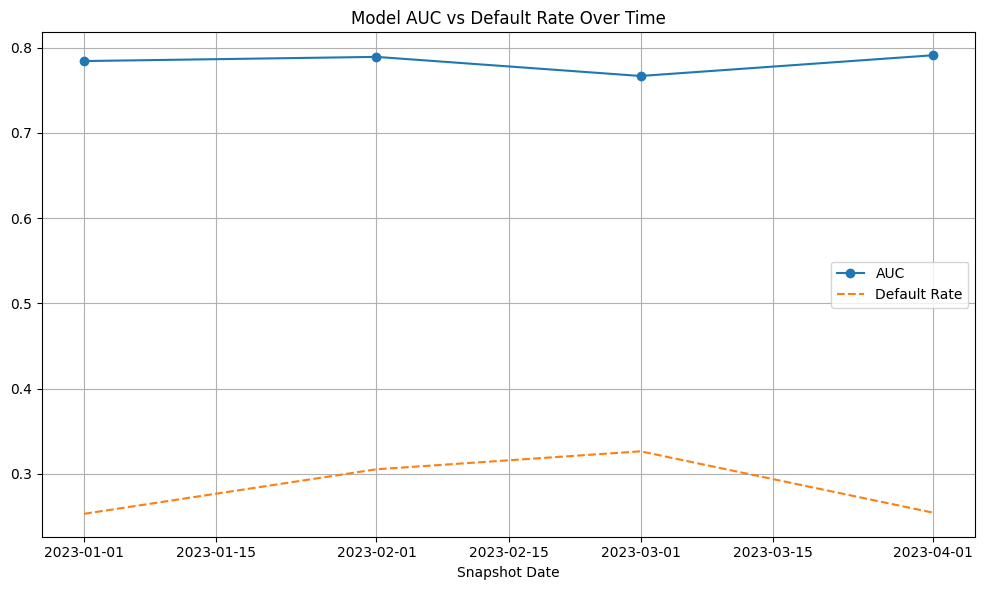

In [24]:
# --- Visualization ---
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(monthly_perf["feature_snapshot_date"], monthly_perf["AUC"], marker='o', label='AUC')
plt.plot(monthly_perf["feature_snapshot_date"], monthly_perf["DefaultRate"], linestyle='--', label='Default Rate')
plt.title("Model AUC vs Default Rate Over Time")
plt.xlabel("Snapshot Date")
plt.legend(); plt.grid(); plt.tight_layout()

reports_dir = "reports/"
os.makedirs(reports_dir, exist_ok=True)
plt.savefig(os.path.join(reports_dir, f"model_perf_trend_{snapshot_date_str.replace('-', '_')}.png"))
print(f"Saved visualization to {reports_dir}")

In [12]:
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-arm64"
os.environ["PATH"] += os.pathsep + os.path.join(os.environ["JAVA_HOME"], "bin")

# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/26 07:47:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [13]:
preds_df = spark.read.parquet("datamart/gold/model_predictions/credit_model_2024_09_01/*.parquet").toPandas()

In [16]:
label_df = spark.read.parquet("datamart/gold/label_store/*.parquet").toPandas()
merged_df = preds_df.merge(label_df, on=["Customer_ID"], how="left")

In [17]:
merged_df

,Customer_ID,feature_snapshot_date,model_name,model_predictions,label,label_def,snapshot_date
0,CUS_0xabf6,2023-03-01,credit_model_2024_09_01.pkl,0.050510,0,30dpd_6mob,2023-09-01
1,CUS_0xac5c,2023-03-01,credit_model_2024_09_01.pkl,0.729269,1,30dpd_6mob,2023-09-01
2,CUS_0xac95,2023-03-01,credit_model_2024_09_01.pkl,0.527662,0,30dpd_6mob,2023-09-01
3,CUS_0xacd4,2023-03-01,credit_model_2024_09_01.pkl,0.609461,1,30dpd_6mob,2023-09-01
4,CUS_0xad7e,2023-03-01,credit_model_2024_09_01.pkl,0.111866,0,30dpd_6mob,2023-09-01
...,...,...,...,...,...,...,...
7843,CUS_0x9967,2023-09-01,credit_model_2024_09_01.pkl,0.059696,0,30dpd_6mob,2024-03-01
7844,CUS_0x998f,2023-09-01,credit_model_2024_09_01.pkl,0.089640,0,30dpd_6mob,2024-03-01
7845,CUS_0x9a58,2023-09-01,credit_model_2024_09_01.pkl,0.110320,0,30dpd_6mob,2024-03-01
7846,CUS_0x9b3c,2023-09-01,credit_model_2024_09_01.pkl,0.305626,0,30dpd_6mob,2024-03-01


In [22]:
monthly_perf = (
    merged_df.groupby("feature_snapshot_date", group_keys=False)
    .apply(lambda x: pd.Series({
        "AUC": roc_auc_score(x["label"], x["model_predictions"]) if x["label"].notna().any() else np.nan,
        "DefaultRate": x["label"].mean(),
        "PredMean": x["model_predictions"].mean(),
        "PredStd": x["model_predictions"].std(),
        "Count": len(x)
    }))
    .reset_index()
)

monthly_perf

/tmp/ipykernel_884/1490492943.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,feature_snapshot_date,AUC,DefaultRate,PredMean,PredStd,Count
0,2023-01-01,0.784239,0.253219,0.254831,0.201848,466.0
1,2023-02-01,0.789142,0.305430,0.275661,0.214151,442.0
2,2023-03-01,0.766742,0.326484,0.289898,0.213645,438.0
3,2023-04-01,0.791046,0.254587,0.269756,0.202228,436.0
4,2023-05-01,0.854665,0.259657,0.278609,0.208055,466.0
5,2023-06-01,0.825659,0.258206,0.257718,0.201487,457.0
6,2023-07-01,0.876573,0.304850,0.298496,0.226616,433.0
7,2023-08-01,0.894934,0.272941,0.270181,0.212714,425.0
8,2023-09-01,0.879074,0.246114,0.264305,0.214865,386.0
9,2023-10-01,0.896672,0.263033,0.272920,0.225462,422.0


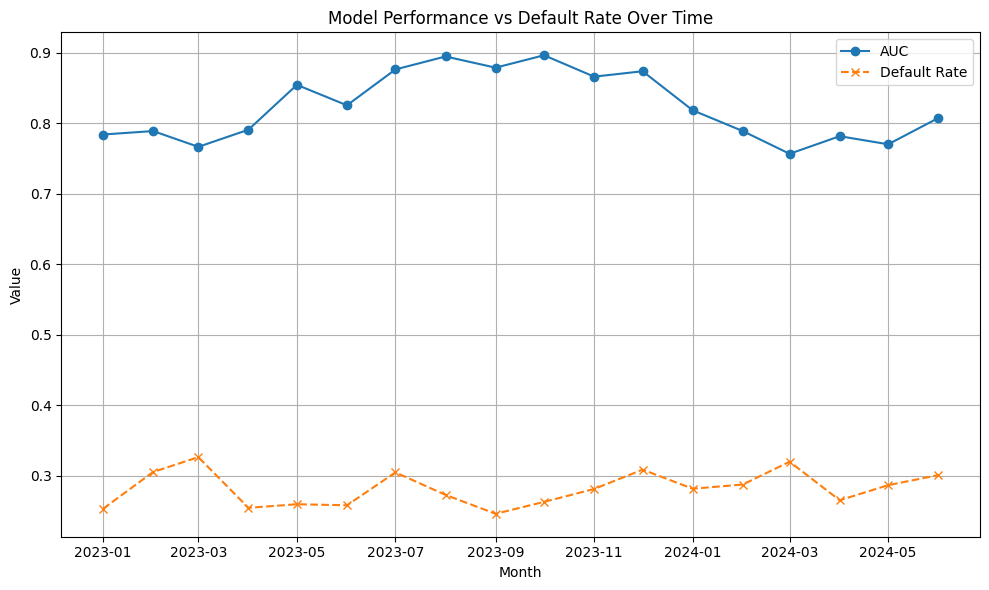

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(monthly_perf["feature_snapshot_date"], monthly_perf["AUC"], label="AUC", marker='o')
plt.plot(monthly_perf["feature_snapshot_date"], monthly_perf["DefaultRate"], label="Default Rate", linestyle="--", marker='x')
plt.title("Model Performance vs Default Rate Over Time")
plt.xlabel("Month"); plt.ylabel("Value")
plt.legend(); plt.grid(); plt.tight_layout()
plt.show()


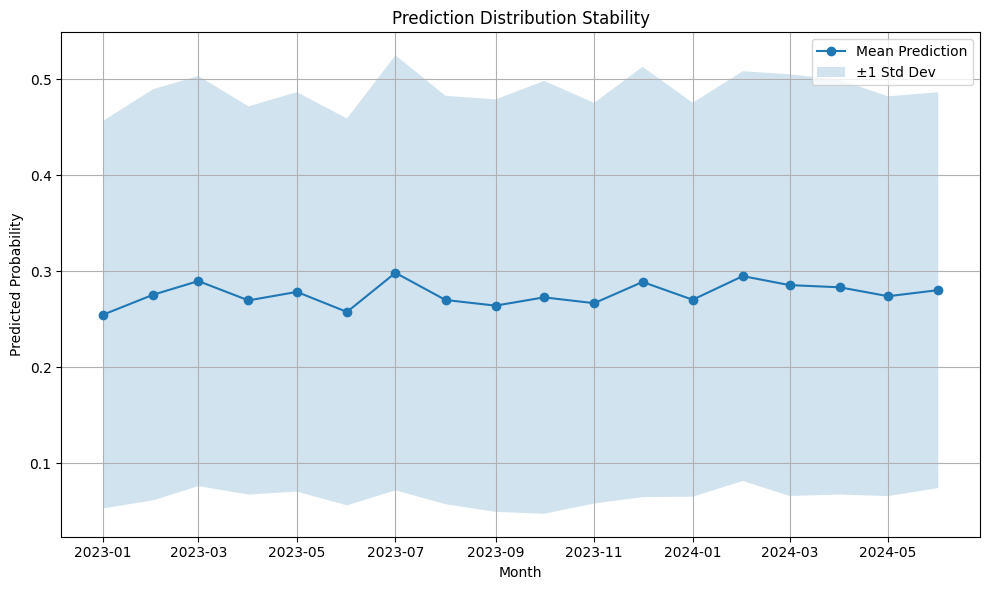

In [24]:
plt.figure(figsize=(10,6))
plt.plot(monthly_perf["feature_snapshot_date"], monthly_perf["PredMean"], label="Mean Prediction", marker='o')
plt.fill_between(monthly_perf["feature_snapshot_date"],
                 monthly_perf["PredMean"] - monthly_perf["PredStd"],
                 monthly_perf["PredMean"] + monthly_perf["PredStd"], alpha=0.2, label="±1 Std Dev")
plt.title("Prediction Distribution Stability")
plt.xlabel("Month"); plt.ylabel("Predicted Probability")
plt.legend(); plt.grid(); plt.tight_layout()
plt.show()

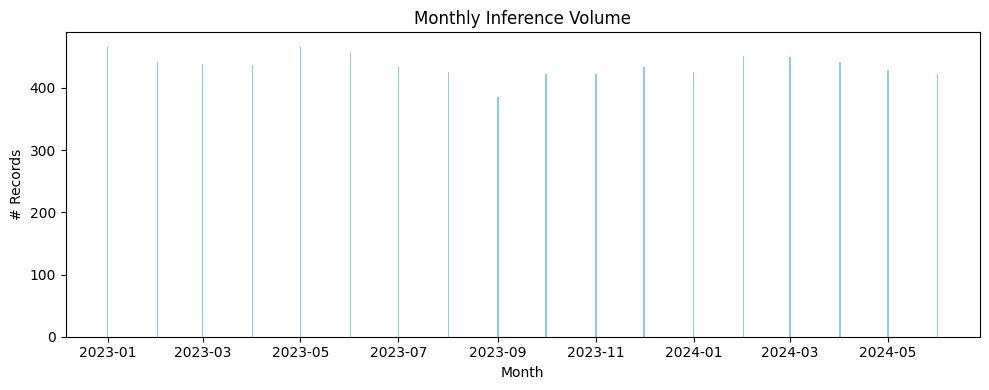

In [25]:
plt.figure(figsize=(10,4))
plt.bar(monthly_perf["feature_snapshot_date"], monthly_perf["Count"], color='skyblue')
plt.title("Monthly Inference Volume")
plt.xlabel("Month"); plt.ylabel("# Records")
plt.tight_layout(); plt.show()


In [26]:
def detect_drift(df, auc_threshold=0.05, pred_mean_shift=0.03):
    ref_auc = df["AUC"].iloc[0]
    ref_pred_mean = df["PredMean"].iloc[0]
    df["AUC_Drift"] = abs(df["AUC"] - ref_auc) > auc_threshold
    df["PredMean_Drift"] = abs(df["PredMean"] - ref_pred_mean) > pred_mean_shift
    df["DriftDetected"] = df["AUC_Drift"] | df["PredMean_Drift"]
    return df

monthly_perf = detect_drift(monthly_perf)
print(monthly_perf[monthly_perf["DriftDetected"]])


   feature_snapshot_date       AUC  DefaultRate  PredMean   PredStd  Count  \
2             2023-03-01  0.766742     0.326484  0.289898  0.213645  438.0   
4             2023-05-01  0.854665     0.259657  0.278609  0.208055  466.0   
6             2023-07-01  0.876573     0.304850  0.298496  0.226616  433.0   
7             2023-08-01  0.894934     0.272941  0.270181  0.212714  425.0   
8             2023-09-01  0.879074     0.246114  0.264305  0.214865  386.0   
9             2023-10-01  0.896672     0.263033  0.272920  0.225462  422.0   
10            2023-11-01  0.866293     0.281324  0.266848  0.208723  423.0   
11            2023-12-01  0.874005     0.308756  0.288963  0.224119  434.0   
13            2024-02-01  0.789130     0.287611  0.295057  0.213414  452.0   
14            2024-03-01  0.756876     0.320000  0.285676  0.219654  450.0   

    AUC_Drift  PredMean_Drift  DriftDetected  
2       False            True           True  
4        True           False           True  
